In [1]:
import numpy as np
import tensorflow as tf
import os
import matplotlib.pyplot as plt

from tensorflow.keras.utils import (
    image_dataset_from_directory,
    load_img,
    img_to_array
)

from tensorflow.keras.models import Sequential

from tensorflow.keras.layers import (
    Dense,
    Dropout,
    GlobalAveragePooling2D,
    RandomFlip,
    RandomRotation,
    RandomZoom,
    Rescaling
)

from tensorflow.keras.applications import VGG16

### Loading the data

In [ ]:
IMG_SIZE = (224, 224)
BATCH_SIZE = 2

dataset_path = "DATASETS/marvel_character_recognition"
#ds_path = "DATASETS/marvel/train"

train_ds, val_ds = image_dataset_from_directory(
    dataset_path,
    validation_split=0.2,
    subset="both",
    seed=42,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE
)


Found 6070 files belonging to 3 classes.
Using 4856 files for training.
Using 1214 files for validation.


In [5]:
for images, labels in train_ds.take(1):
    print(images.shape)
    print(images.dtype)
    print(labels)

(2, 224, 224, 3)
<dtype: 'float32'>
tf.Tensor([0 1], shape=(2,), dtype=int32)


In [6]:
class_names = train_ds.class_names

print("\nClasses Found:")
print(class_names)


Classes Found:
['marvel', 'train', 'valid']


### Data Augmentation

In [7]:
data_augmentation = Sequential([
    RandomFlip("horizontal"),
    RandomRotation(0.2),
    RandomZoom(0.2)
])

### Load pretrained VGG16

In [8]:
base_model = VGG16(
    weights='imagenet',
    include_top=False,
    input_shape=(224,224,3)
)

base_model.trainable = False

58889256/58889256 ━━━━━━━━━━━━━━━━━━━━ 9s 0us/step


# Building the Final Model

In [9]:
model = Sequential([
    data_augmentation,

    Rescaling(1./255),

    base_model,

    GlobalAveragePooling2D(),

    Dense(128, activation="relu"),

    Dropout(0.3),

    Dense(4, activation="softmax")
])


### Compile the model

In [10]:
model.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

### Train the model

In [11]:
history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=10,
)

Epoch 1/10


 363/2428 ━━━━━━━━━━━━━━━━━━━━ 10:48 314ms/step - accuracy: 0.4409 - loss: 1.0874

KeyboardInterrupt: 

In [ ]:
print(history.history["loss"])
print(history.history["accuracy"])

[1.5718348026275635, 1.624042272567749, 1.4974397420883179, 1.283177137374878, 1.1659562587738037, 1.2328368425369263, 1.3268346786499023, 1.126138687133789, 1.1125342845916748, 0.9465689659118652]
[0.0, 0.0, 0.20000000298023224, 0.30000001192092896, 0.5, 0.20000000298023224, 0.4000000059604645, 0.699999988079071, 0.6000000238418579, 0.800000011920929]


### Testing on new Images

W0000 00:00:1781752373.698971   12620 bfc_allocator.cc:311] Allocator (GPU_0_bfc) ran out of memory trying to allocate 2.06GiB with freed_by_count=0. The caller indicates that this is not a failure, but this may mean that there could be performance gains if more memory were available.
W0000 00:00:1781752373.907908   12620 bfc_allocator.cc:311] Allocator (GPU_0_bfc) ran out of memory trying to allocate 2.06GiB with freed_by_count=0. The caller indicates that this is not a failure, but this may mean that there could be performance gains if more memory were available.
W0000 00:00:1781752374.174511   12620 bfc_allocator.cc:311] Allocator (GPU_0_bfc) ran out of memory trying to allocate 2.09GiB with freed_by_count=0. The caller indicates that this is not a failure, but this may mean that there could be performance gains if more memory were available.
W0000 00:00:1781752374.395638   12620 bfc_allocator.cc:311] Allocator (GPU_0_bfc) ran out of memory trying to allocate 2.15GiB with freed_by_c

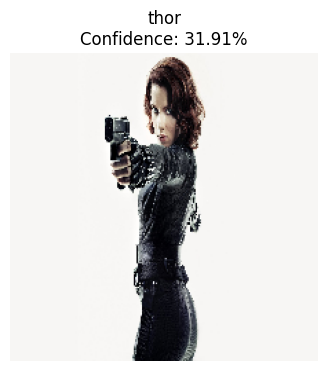

image2.jpg -> thor (31.91%)


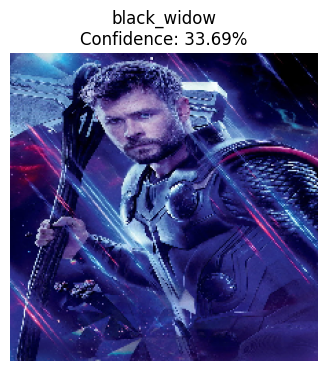

image1.jpg -> black_widow (33.69%)


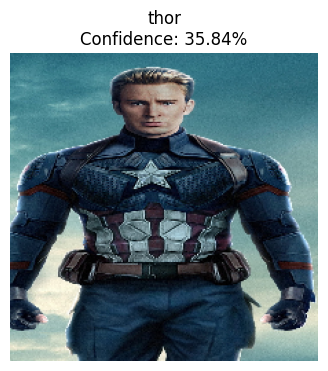

image3.jpg -> thor (35.84%)


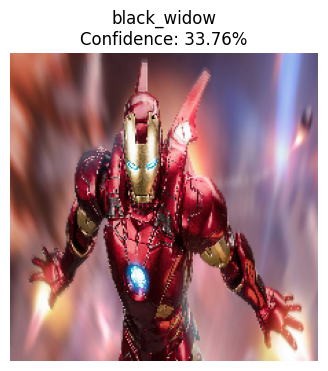

image4.jpg -> black_widow (33.76%)


In [11]:
test_folder = "DATASETS/test_images"

for image_name in os.listdir(test_folder):

    image_path = os.path.join(
        test_folder,
        image_name
    )

    img = load_img(
        image_path,
        target_size=(224,224)
    )

    img_array = img_to_array(img)

    img_array = np.expand_dims(
        img_array,
        axis=0
    )

    prediction = model.predict(
        img_array,
        verbose=0
    )

    predicted_class = class_names[
        np.argmax(prediction)
    ]

    confidence = np.max(prediction)

    plt.figure(figsize=(4,4))
    plt.imshow(img)
    plt.axis("off")

    plt.title(
        f"{predicted_class}\nConfidence: {confidence*100:.2f}%"
    )

    plt.show()

    print(
        f"{image_name} -> {predicted_class} ({confidence*100:.2f}%)"
    )